### Partie 4 : Visualisation (3-4h)

**Competence evaluee : C2.4 - Presenter des donnees analysees de facon intelligible**

#### Etape 4.1 : Graphiques Matplotlib
Produire les visualisations suivantes avec Matplotlib :

1. Evolution temporelle de la consommation totale par type d'energie (line plot)
2. Distribution des consommations par type de batiment (boxplot)
3. Heatmap consommation moyenne par heure et jour de semaine
4. Scatter plot temperature vs consommation de chauffage avec regression
5. Comparaison consommation par classe energetique (bar chart)

Chaque graphique doit inclure : titre explicite, labels des axes avec unites, legende, annotations pertinentes.

**Livrables** :
- Notebook `09_visualisations_matplotlib.ipynb`
- 5 figures PNG (300 dpi) dans `output/figures/`

In [63]:
import os
import pandas as pd

INPUT_DIR = os.path.join("../output", "consommations_enrichies.csv")
OUTPUT_DIR = os.path.join("../output", "figures")
INPUT_METEO = os.path.join("../output", "meteo_clean.csv")




In [64]:
df_conso = pd.read_csv(INPUT_DIR)
df_meteo = pd.read_csv(INPUT_METEO)

df_fusion_meteo = df_conso \
    .merge(
        df_meteo, on = ['date', 'hour', 'commune', 'month'],
        how = "left"
    )

print(df_fusion_meteo)

print("colonnes :\n",df_conso.dtypes)
print("nb lignes :\n", len(df_conso))

         Unnamed: 0 batiment_id         type   commune type_energie  \
0                 0     BAT0001        ecole     Paris          eau   
1                 1     BAT0139      piscine    Toulon          eau   
2                 2     BAT0001        ecole     Paris          eau   
3                 3     BAT0139      piscine    Toulon          eau   
4                 4     BAT0001        ecole     Paris          eau   
...             ...         ...          ...       ...          ...   
7492579     7492579     BAT0034  mediatheque  Toulouse          gaz   
7492580     7492580     BAT0034  mediatheque  Toulouse          gaz   
7492581     7492581     BAT0035       mairie  Toulouse          gaz   
7492582     7492582     BAT0035       mairie  Toulouse          gaz   
7492583     7492583     BAT0035       mairie  Toulouse          gaz   

         conso_clean unite        date  hour  year  ...  conso_annuelle  \
0               2.13    m3  2023-01-01     6  2023  ...      3054953.60 

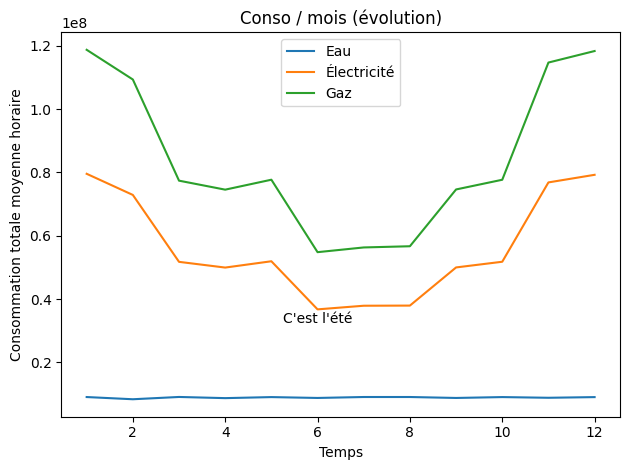

In [79]:
df_par_month = df_conso.groupby(["month", "type_energie"],as_index=False).agg(
    conso_totale=("conso_clean", "sum")
)

import matplotlib.pyplot as plt

plt.plot(
    df_par_month[df_par_month["type_energie"] == "eau"]["month"],
    df_par_month[df_par_month["type_energie"] == "eau"]["conso_totale"],
    label="Eau"
)

plt.plot(
    df_par_month[df_par_month["type_energie"] == "electricite"]["month"],
    df_par_month[df_par_month["type_energie"] == "electricite"]["conso_totale"],
    label="Électricité"
)

plt.plot(
    df_par_month[df_par_month["type_energie"] == "gaz"]["month"],
    df_par_month[df_par_month["type_energie"] == "gaz"]["conso_totale"],
    label="Gaz"
)

#annotation pertinente
idx_min = df_par_month.loc[
    df_par_month["type_energie"] == "electricite",
    "conso_totale"
].idxmin()

plt.annotate(
    "C'est l'été",
    (
        df_par_month.loc[idx_min, "month"],
        df_par_month.loc[idx_min, "conso_totale"]
    ),
    xytext=(0, -10),
    textcoords="offset points",
    ha="center"
)

plt.xlabel("Temps")
plt.ylabel("Consommation totale moyenne horaire")
plt.title("Conso / mois (évolution)")
plt.legend()
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/evol_conso_energie_mois.png", dpi=300, bbox_inches="tight")

plt.show()



2. Distribution des consommations par type de batiment (boxplot)

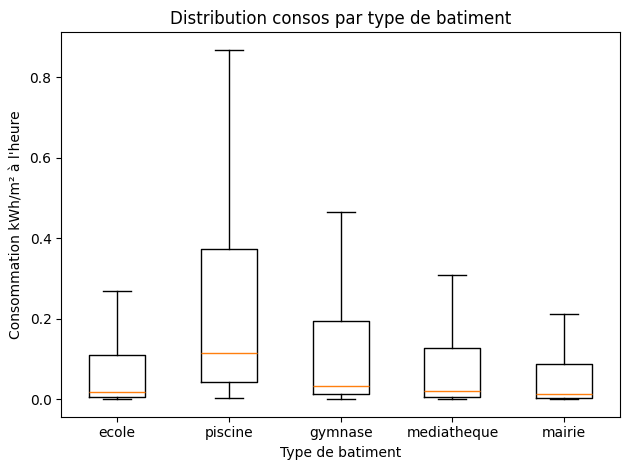

In [80]:
types = df_conso["type"].unique()
data = [df_conso[df_conso["type"] == t]["conso_m2"].dropna() for t in types]

plt.figure()
plt.boxplot(data, tick_labels=types, showfliers=False)

plt.xlabel("Type de batiment")
plt.ylabel("Consommation kWh/m² à l'heure")
plt.title("Distribution consos par type de batiment")

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/cosno_type_batiment.png", dpi=300, bbox_inches="tight")

plt.show()



3. Heatmap consommation moyenne par heure et jour de semaine


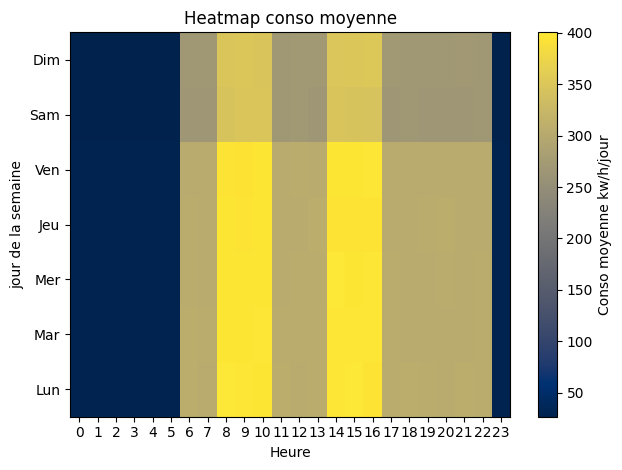

In [81]:

df_conso["date"] = pd.to_datetime(df_conso["date"], errors="coerce")
df_conso["day_week"] = df_conso["date"].dt.dayofweek

df_heatmap = df_conso.groupby(
    ["day_week", "hour"],
    as_index=False
).agg(
    conso_moyenne=("conso_clean", "mean")
)


plt.figure()

plt.imshow(
    df_heatmap.pivot(
        index="day_week",
        columns="hour",
        values="conso_moyenne"
    ),
    aspect="auto",
    origin="lower",
    cmap="cividis"
)

plt.colorbar(label="Conso moyenne kw/h/jour")

plt.xlabel("Heure")
plt.ylabel("jour de la semaine")

plt.xticks(range(24), range(24))
plt.yticks(range(7), ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])

plt.title("Heatmap conso moyenne")

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/heatmap_conso_heure_jour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


On peut voir que la nuit et le weekend, la consommation est inférieure. Elle est plus forte durant les heures de bureau.

4. Scatter plot temperature vs consommation de chauffage avec regression

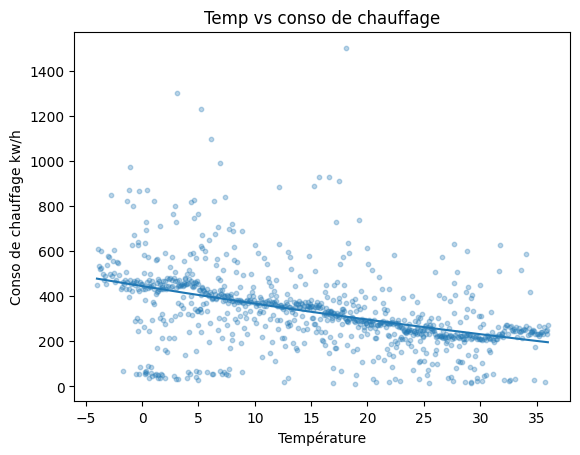

In [84]:
import numpy as np


df_chaufferie = df_fusion_meteo[
    df_fusion_meteo["type_energie"].isin(["gaz", "electricite"])
]

df_chaufferie = df_chaufferie.groupby(
    ["temperature_c"],
    as_index=False
).agg(
    frais_chauffe=("conso_clean", "mean")
)


plt.figure()

plt.scatter(
    df_chaufferie["temperature_c"],
    df_chaufferie["frais_chauffe"],
    alpha=0.3,
    s=10
)

x = df_chaufferie["temperature_c"].values
y = df_chaufferie["frais_chauffe"].values

coef = np.polyfit(x, y, 2)
poly = np.poly1d(coef)

x_droite = np.linspace(x.min(), x.max(), 200)
y_droite = poly(x_droite)

plt.plot(x_droite, y_droite)

plt.xlabel("Température")
plt.ylabel("Conso de chauffage kw/h")
plt.title("Temp vs conso de chauffage")

plt.savefig(
    f"{OUTPUT_DIR}/scatter_conso_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

5. Comparaison consommation par classe energetique (bar chart)

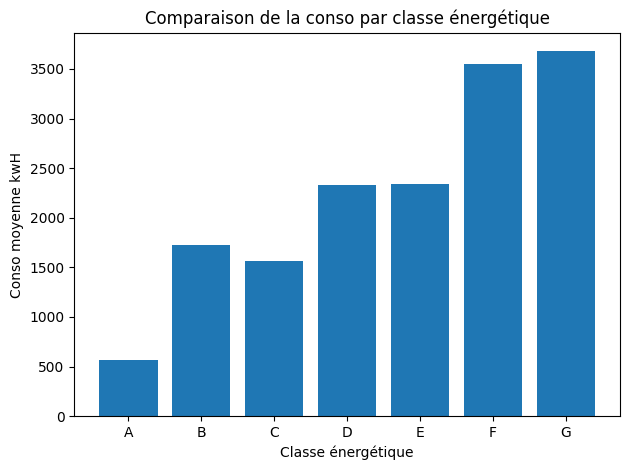

In [83]:
df_classe_ener = df_conso.groupby(
    "classe_energetique",
    as_index=False
).agg(
    conso_moyenne=("conso_m2_annee", "mean")
)

df_classe_ener = df_classe_ener.sort_values("classe_energetique")


plt.figure()

plt.bar(
    df_classe_ener["classe_energetique"],
    df_classe_ener["conso_moyenne"]
)

plt.xlabel("Classe énergétique")
plt.ylabel("Conso moyenne kwH")
plt.title("Comparaison de la conso par classe énergétique")

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/bar_conso_par_classe_energetique.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()